<a href="https://colab.research.google.com/github/varshiniv-dev/internship-ai/blob/main/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

In [54]:
# Load the e-commerce dataset
df = pd.read_csv('ecommerce_sales_dataset.csv')

# Display the first 5 rows
df.head()

,Order_ID,Product_Category,Price,Quantity,Customer_Rating
0,1001,Books,1894,4,3.8
1,1002,Electronics,2210,1,4.6
2,1003,Clothing,897,2,4.2
3,1004,Clothing,3890,1,2.8
4,1005,Electronics,3529,3,3.6


In [55]:
# Calculate total sales/revenue for each product
# Formula: Price × Quantity

df['Total_Sales'] = df['Price'] * df['Quantity']

# Display the updated dataset
df.head()

# Display the Total_Sales column
df[['Price', 'Quantity', 'Total_Sales']].head()

,Price,Quantity,Total_Sales
0,1894,4,7576
1,2210,1,2210
2,897,2,1794
3,3890,1,3890
4,3529,3,10587


In [56]:

# Calculate total sales for each product category
category_sales = df.groupby('Product_Category')['Total_Sales'].sum()

# Sort categories from highest sales to lowest sales
category_sales = category_sales.sort_values(ascending=False)

# Display the sales generated by each category
print("Total Sales by Category:")
print(category_sales)

Total Sales by Category:
Product_Category
Home           71874
Electronics    38910
Clothing       24963
Books           7576
Name: Total_Sales, dtype: int64


In [57]:
# Identify the category with the highest total sales
top_category = category_sales.idxmax()

# Get the highest sales value
top_category_sales = category_sales.max()

print("Top-Performing Category:", top_category)
print("Total Sales:", top_category_sales)

Top-Performing Category: Home
Total Sales: 71874


In [58]:
# Identify the category with the lowest total sales
lowest_category = category_sales.idxmin()

# Get the lowest sales value
lowest_category_sales = category_sales.min()

print("Lowest-Performing Category:", lowest_category)
print("Total Sales:", lowest_category_sales)

Lowest-Performing Category: Books
Total Sales: 7576


In [59]:
# Calculate the average product rating
average_rating = df['Customer_Rating'].mean()

print("Average Product Rating:", round(average_rating, 2))

Average Product Rating: 3.86


In [60]:
# Interpret the average customer rating

if average_rating >= 4:
    print("Interpretation: Customers are generally satisfied with the products.")
elif average_rating >= 3:
    print("Interpretation: Customer satisfaction is moderate.")
else:
    print("Interpretation: Customer satisfaction is relatively low and may need improvement.")

Interpretation: Customer satisfaction is moderate.


In [61]:
# Filter products with a rating greater than 4
premium_products = df[df['Customer_Rating'] > 4]

# Display the premium/highly-rated products
print("Premium Products (Rating > 4):")

premium_products

Premium Products (Rating > 4):


,Order_ID,Product_Category,Price,Quantity,Customer_Rating,Total_Sales
1,1002,Electronics,2210,1,4.6,2210
2,1003,Clothing,897,2,4.2,1794
5,1006,Home,2228,2,4.7,4456
6,1007,Home,697,3,4.8,2091
7,1008,Home,2349,4,4.8,9396
9,1010,Home,3080,5,4.4,15400
11,1012,Electronics,1679,1,4.8,1679
12,1013,Home,2130,2,4.2,4260
15,1016,Home,2703,4,5.0,10812
19,1020,Clothing,2759,5,5.0,13795


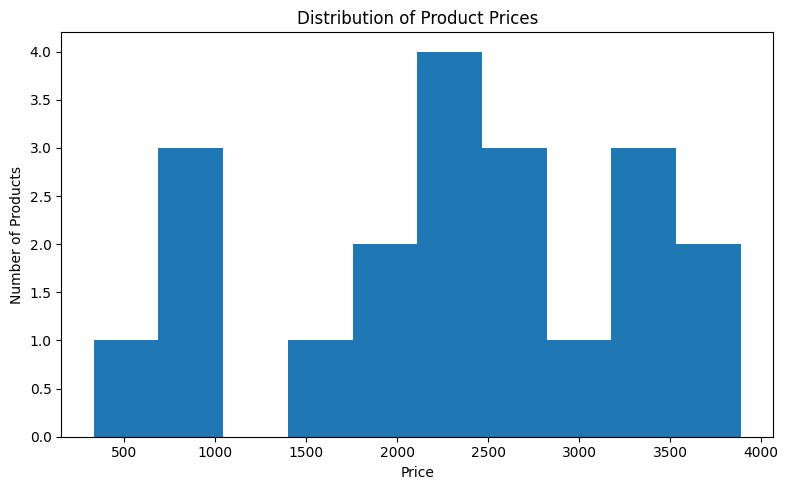

In [62]:
# Create a histogram showing the distribution of product prices

plt.figure(figsize=(8, 5))

plt.hist(df['Price'], bins=10)

# Add chart title
plt.title('Distribution of Product Prices')

# Add axis labels
plt.xlabel('Price')
plt.ylabel('Number of Products')

# Adjust layout
plt.tight_layout()

# Display the histogram
plt.show()

In [63]:
# Calculate basic statistics for product prices

print("Minimum Price:", df['Price'].min())
print("Maximum Price:", df['Price'].max())
print("Average Price:", round(df['Price'].mean(), 2))
print("Median Price:", df['Price'].median())

Minimum Price: 331
Maximum Price: 3890
Average Price: 2334.05
Median Price: 2288.5


In [64]:
# Create price ranges using 10 equal-width bins
price_ranges = pd.cut(df['Price'], bins=10)

# Count how many products fall into each price range
price_distribution = price_ranges.value_counts().sort_index()

print("Number of Products in Each Price Range:")
print(price_distribution)

Number of Products in Each Price Range:
Price
(327.441, 686.9]    1
(686.9, 1042.8]     3
(1042.8, 1398.7]    0
(1398.7, 1754.6]    1
(1754.6, 2110.5]    2
(2110.5, 2466.4]    4
(2466.4, 2822.3]    3
(2822.3, 3178.2]    1
(3178.2, 3534.1]    3
(3534.1, 3890.0]    2
Name: count, dtype: int64


In [65]:
# Identify the price range containing the highest number of products

most_common_price_range = price_distribution.idxmax()
number_of_products = price_distribution.max()

print("Most Common Price Range:", most_common_price_range)
print("Number of Products:", number_of_products)

Most Common Price Range: (2110.5, 2466.4]
Number of Products: 4


In [66]:
# FINAL BUSINESS SUMMARY

print("========== E-COMMERCE SALES PERFORMANCE SUMMARY ==========")

# Top-performing category
print("\n1. Top-Performing Category:")
print(top_category)

print("   Total Sales:", top_category_sales)

# Lowest-performing category
print("\n2. Lowest-Performing Category:")
print(lowest_category)

print("   Total Sales:", lowest_category_sales)

# Customer satisfaction
print("\n3. Customer Satisfaction:")
print("   Average Product Rating:", round(average_rating, 2))

# Premium products
print("\n4. Premium Products:")
print("   Number of products with Rating > 4:", len(premium_products))

# Pricing
print("\n5. Pricing Analysis:")
print("   Average Price:", round(df['Price'].mean(), 2))
print("   Most Common Price Range:", most_common_price_range)

print("\n==========================================================")

========== E-COMMERCE SALES PERFORMANCE SUMMARY ==========

1. Top-Performing Category:
Home
   Total Sales: 71874

2. Lowest-Performing Category:
Books
   Total Sales: 7576

3. Customer Satisfaction:
   Average Product Rating: 3.86

4. Premium Products:
   Number of products with Rating > 4: 10

5. Pricing Analysis:
   Average Price: 2334.05
   Most Common Price Range: (2110.5, 2466.4]



In [67]:
# DATA-DRIVEN RECOMMENDATIONS

print("========== INVENTORY RECOMMENDATIONS ==========")

# Recommendation 1: Focus on the highest-revenue category
print(f"\n1. Increase inventory focus on '{top_category}'.")
print("   This category generates the highest total sales and should receive priority.")

# Recommendation 2: Review the lowest-performing category
print(f"\n2. Review the performance of '{lowest_category}'.")
print("   Its lower sales performance suggests that inventory levels should be evaluated.")

# Recommendation 3: Leverage highly-rated products
print("\n3. Prioritize highly-rated products.")
print(f"   There are {len(premium_products)} products with ratings above 4.")
print("   These products can be considered strong candidates for continued promotion and stocking.")

# Recommendation 4: Use pricing distribution for inventory planning
print("\n4. Consider the most common product price range.")
print(f"   The most common price range is {most_common_price_range}.")
print("   Inventory planning should consider demand concentration within this price range.")

print("\n================================================")

========== INVENTORY RECOMMENDATIONS ==========

1. Increase inventory focus on 'Home'.
   This category generates the highest total sales and should receive priority.

2. Review the performance of 'Books'.
   Its lower sales performance suggests that inventory levels should be evaluated.

3. Prioritize highly-rated products.
   There are 10 products with ratings above 4.
   These products can be considered strong candidates for continued promotion and stocking.

4. Consider the most common product price range.
   The most common price range is (2110.5, 2466.4].
   Inventory planning should consider demand concentration within this price range.

